# 读入数据

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ab_data_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date

df.head()

,user_id,timestamp,group,landing_page,converted,date
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21


# 每日转化率曲线

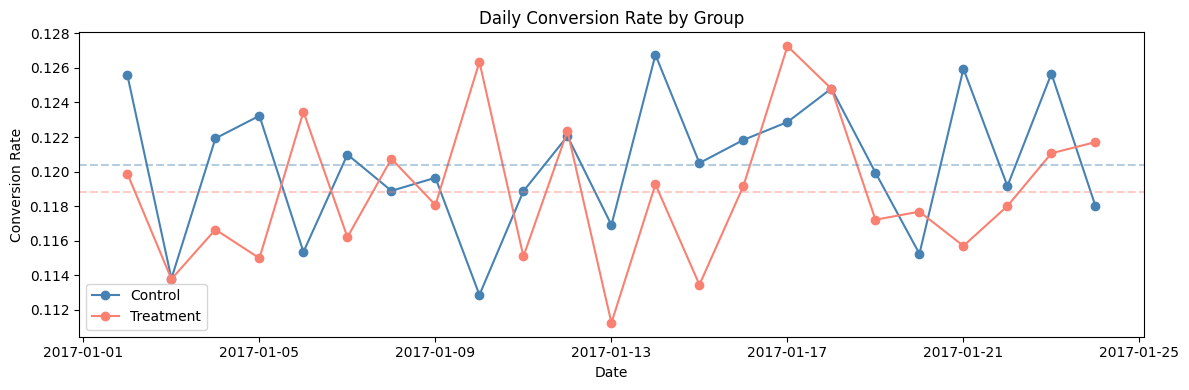

In [3]:
daily_cr = df.groupby(["date", "group"])["converted"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 4))
daily_cr["control"].plot(ax=ax, label="Control", color="steelblue", marker="o")
daily_cr["treatment"].plot(ax=ax, label="Treatment", color="salmon", marker="o")

ax.set_title("Daily Conversion Rate by Group")
ax.set_ylabel("Conversion Rate")
ax.set_xlabel("Date")
ax.legend()
ax.axhline(
    y=df[df["group"] == "control"]["converted"].mean(),
    color="steelblue",
    linestyle="--",
    alpha=0.4,
)
ax.axhline(
    y=df[df["group"] == "treatment"]["converted"].mean(),
    color="salmon",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()
plt.savefig(
    r"D:\VsCodeProjects\AB_Test_Analysis\figures\daily_conversion_rate.png", dpi=150
)
plt.show()

# 累积转化率曲线

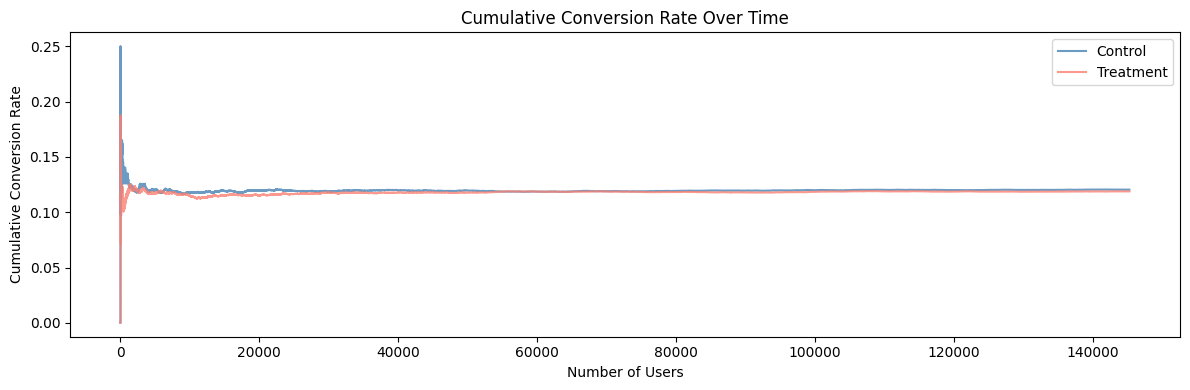

In [4]:
df_sorted = df.sort_values("timestamp")

control_cum = df_sorted[df_sorted["group"] == "control"]["converted"].expanding().mean()
treatment_cum = (
    df_sorted[df_sorted["group"] == "treatment"]["converted"].expanding().mean()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(control_cum.values, label="Control", color="steelblue", alpha=0.8)
ax.plot(treatment_cum.values, label="Treatment", color="salmon", alpha=0.8)

ax.set_title("Cumulative Conversion Rate Over Time")
ax.set_ylabel("Cumulative Conversion Rate")
ax.set_xlabel("Number of Users")
ax.legend()

plt.tight_layout()
plt.savefig(
    r"D:\VsCodeProjects\AB_Test_Analysis\figures/cumulative_conversion_rate.png",
    dpi=150,
)
plt.show()

# 按星期分群分析

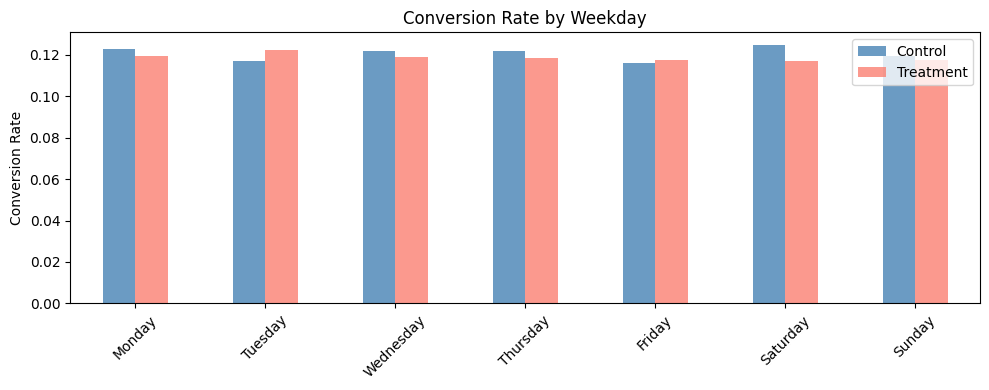

In [5]:
df["weekday"] = df["timestamp"].dt.day_name()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_cr = df.groupby(["weekday", "group"])["converted"].mean().unstack()
weekday_cr = weekday_cr.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(10, 4))
weekday_cr.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], alpha=0.8)

ax.set_title("Conversion Rate by Weekday")
ax.set_ylabel("Conversion Rate")
ax.set_xlabel("")
ax.legend(["Control", "Treatment"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    r"D:\VsCodeProjects\AB_Test_Analysis\figures/weekday_conversion_rate.png", dpi=150
)
plt.show()

# 按小时分群分析

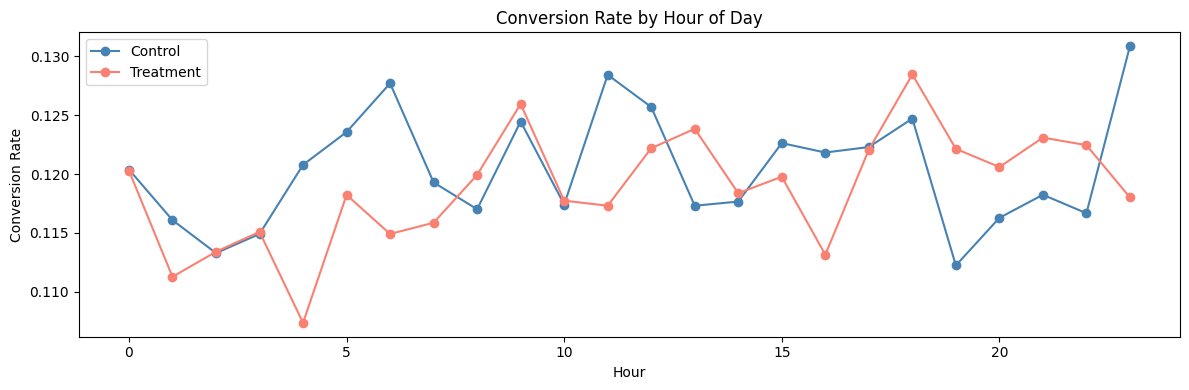

In [6]:
df["hour"] = df["timestamp"].dt.hour

hour_cr = df.groupby(["hour", "group"])["converted"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 4))
hour_cr["control"].plot(ax=ax, label="Control", color="steelblue", marker="o")
hour_cr["treatment"].plot(ax=ax, label="Treatment", color="salmon", marker="o")

ax.set_title("Conversion Rate by Hour of Day")
ax.set_ylabel("Conversion Rate")
ax.set_xlabel("Hour")
ax.legend()
plt.tight_layout()
plt.savefig(
    r"D:\VsCodeProjects\AB_Test_Analysis\figures/hourly_conversion_rate.png", dpi=150
)
plt.show()